In [6]:
data_dir = '/mount/NAS-public-dataset/HBN-EEG'
file_name = 'participants_combind.tsv'

In [7]:
import pandas as pd
from pathlib import Path

# Build path from existing variables
tsv_path = Path(data_dir) / file_name
if not tsv_path.exists():
    raise FileNotFoundError(f"File not found: {tsv_path}")

# Load TSV and show basic info
df = pd.read_csv(tsv_path, sep="\t", low_memory=False)
print(f"Loaded: {tsv_path}")
print(f"Shape: {df.shape}")
print(f"First columns: {list(df.columns)}")

# Preview a few rows
df.head(10)

Loaded: /mount/NAS-public-dataset/HBN-EEG/participants_combind.tsv
Shape: (1862, 34)
First columns: ['participant_id', 'release_number', 'sex', 'age', 'ehq_total', 'commercial_use', 'full_pheno', 'p_factor', 'attention', 'internalizing', 'externalizing', 'RestingState', 'DespicableMe', 'FunwithFractals', 'ThePresent', 'DiaryOfAWimpyKid', 'contrastChangeDetection_1', 'contrastChangeDetection_2', 'contrastChangeDetection_3', 'surroundSupp_1', 'surroundSupp_2', 'seqLearning6target', 'seqLearning8target', 'symbolSearch', 'smiley_face', 'sad_face', 'non_target', 'miss_target', 'smiley_response_time', 'sad_response_time', 'ccd_total_targets', 'ccd_accuracy', 'ccd_median_rt', 'ccd_response_time']


,participant_id,release_number,sex,age,ehq_total,commercial_use,full_pheno,p_factor,attention,internalizing,...,smiley_face,sad_face,non_target,miss_target,smiley_response_time,sad_response_time,ccd_total_targets,ccd_accuracy,ccd_median_rt,ccd_response_time
0,sub-NDARAC904DMU,R1,F,11.3386,71.17,Yes,Yes,-0.603,-0.446,1.248,...,67.0,NaN,NaN,5.0,"[2.13, 1.96, 2.02, 1.72, 1.8, 1.72, 1.842, 1.5...",[],72.0,93.0556,NaN,1.6142
1,sub-NDARAG143ARJ,R1,M,7.6648,100.05,Yes,Yes,-0.258,-0.425,1.006,...,51.0,9.0,NaN,12.0,"[1.51, 1.95, 1.87, 1.83, 1.8, 2.23, 1.21, 2.34...","[2.12, 1.952, 1.6, 1.75, 1.79, 2.03, 1.42, 1.8...",72.0,70.8333,NaN,1.8137
2,sub-NDARAM704GKZ,R1,M,10.9449,-53.36,Yes,Yes,0.062,-0.119,0.222,...,93.0,1.0,NaN,2.0,"[1.968, 2.09, 1.79, 2.13, 2.05, 2.01, 1.56, 2....",[1.708],96.0,96.8750,NaN,1.5220
3,sub-NDARAN385MDH,R1,M,10.7089,96.72,Yes,Yes,0.034,-0.308,0.455,...,84.0,3.0,NaN,9.0,"[1.98, 2.16, 1.53, 1.77, 2.14, 2.14, 1.31, 1.7...","[1.81, 1.52, 0.21]",96.0,87.5000,NaN,1.6325
4,sub-NDARAP359UM6,R1,F,12.8422,80.04,Yes,Yes,0.467,1.826,1.949,...,90.0,5.0,NaN,1.0,"[1.57, 1.572, 1.31, 1.98, 1.98, 1.61, 1.82, 1....","[1.468, 1.27, 2.03, 1.46, 1.77]",96.0,93.7500,NaN,1.6480
5,sub-NDARAW320CGR,R1,M,6.3619,-54.49,Yes,Yes,1.094,1.087,0.387,...,NaN,NaN,NaN,NaN,[],[],NaN,NaN,NaN,NaN
6,sub-NDARBD879MBX,R1,M,13.9757,86.71,Yes,Yes,0.481,-1.085,-1.124,...,80.0,6.0,NaN,10.0,"[2.08, 2.15, 2.2, 1.92, 2.28, 2.23, 1.76, 1.82...","[2.02, 1.908, 1.99, 1.918, 2.21, 1.698]",96.0,83.3333,NaN,1.6742
7,sub-NDARBH024NH2,R1,F,8.6883,100.05,Yes,Yes,-0.818,-0.507,-1.240,...,32.0,21.0,NaN,43.0,"[0.82, 0.49, 0.99, 1.48, 1.58, 1.1, 1.63, 2.2,...","[0.85, 0.38, 2.33, 0.82, 1.15, 0.45, 1.58, 0.6...",96.0,33.3333,NaN,1.2151
8,sub-NDARBK082PDD,R1,M,8.3652,93.38,Yes,Yes,0.281,-0.081,-0.555,...,80.0,4.0,NaN,12.0,"[1.79, 1.61, 1.45, 1.58, 1.79, 1.92, 1.69, 1.2...","[1.93, 2.36, 1.93, 2.36]",96.0,83.3333,NaN,1.7315
9,sub-NDARBM173BJG,R1,M,11.0566,-86.71,Yes,Yes,-0.662,-1.331,-0.135,...,83.0,4.0,NaN,9.0,"[2.05, 0.92, 2.36, 0.83, 1.49, 1.53, 2.19, 1.3...","[1.8, 1.99, 1.27, 1.27]",96.0,86.4583,NaN,1.5922


In [8]:
# Coerce types and basic stats for CCD metrics
for col in ["ccd_accuracy", "ccd_response_time"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        print(f"Column missing: {col}")
        df[col] = pd.Series(dtype=float)

n_total = len(df)
n_acc = df["ccd_accuracy"].notna().sum()
n_rt = df["ccd_response_time"].notna().sum()
print({"n_rows": n_total, "n_acc": n_acc, "n_rt": n_rt})

print("\nccd_accuracy describe():")
print(df["ccd_accuracy"].describe())
print("median:", df["ccd_accuracy"].median())

print("\nccd_response_time describe():")
print(df["ccd_response_time"].describe())
print("median:", df["ccd_response_time"].median())

{'n_rows': 1862, 'n_acc': np.int64(1327), 'n_rt': np.int64(1326)}

ccd_accuracy describe():
count    1327.000000
mean       74.433452
std        22.187609
min         0.000000
25%        63.888900
50%        81.944400
75%        91.666700
max       100.000000
Name: ccd_accuracy, dtype: float64
median: 81.9444

ccd_response_time describe():
count    1326.000000
mean        1.600225
std         0.217097
min         0.180000
25%         1.500050
50%         1.632400
75%         1.743900
max         2.111700
Name: ccd_response_time, dtype: float64
median: 1.6324


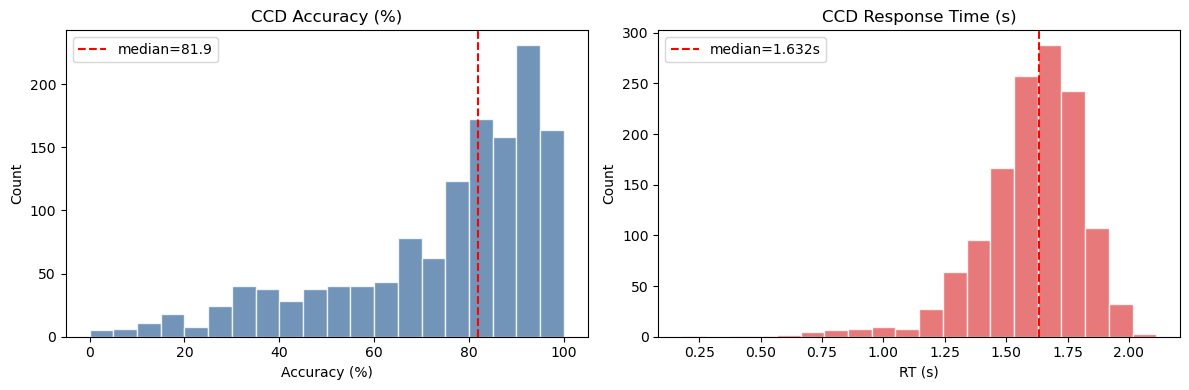

In [9]:
# Histograms for CCD metrics
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
vals = df["ccd_accuracy"].dropna()
if not vals.empty:
    ax.hist(vals, bins=np.linspace(0, 100, 21), color="#4e79a7", alpha=0.8, edgecolor="white")
    ax.set_title("CCD Accuracy (%)")
    ax.set_xlabel("Accuracy (%)")
    ax.set_ylabel("Count")
    ax.axvline(vals.median(), color="red", linestyle="--", label=f"median={vals.median():.1f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No accuracy data", ha="center", va="center")
    ax.set_axis_off()

ax = axes[1]
vals = df["ccd_response_time"].dropna()
if not vals.empty:
    ax.hist(vals, bins=20, color="#e15759", alpha=0.8, edgecolor="white")
    ax.set_title("CCD Response Time (s)")
    ax.set_xlabel("RT (s)")
    ax.set_ylabel("Count")
    ax.axvline(vals.median(), color="red", linestyle="--", label=f"median={vals.median():.3f}s")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No RT data", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

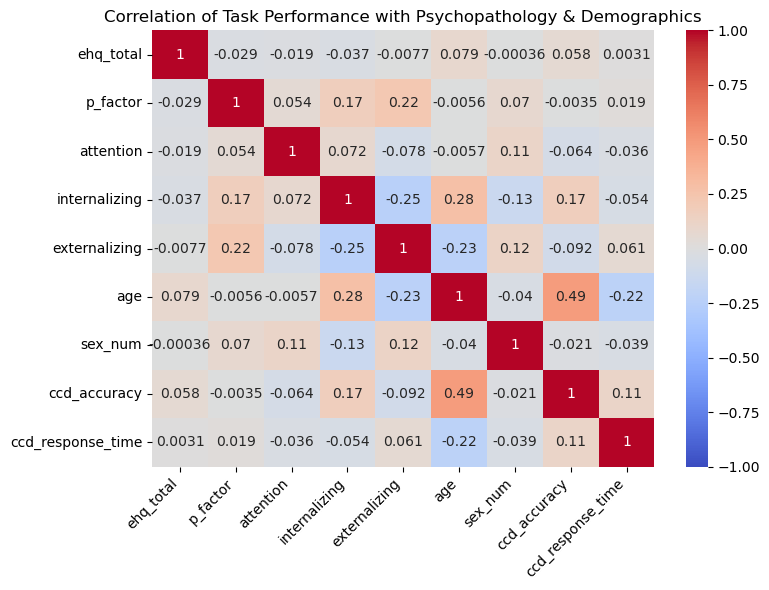

In [22]:
import seaborn as sns
# --- 3. Correlation heatmap (extended with age, sex, performance) ---
df_corr = df.copy()
df_corr["sex_num"] = df_corr["sex"].map({"M":1, "F":0})

heatmap_vars = [
    "ehq_total","p_factor", "attention", "internalizing", "externalizing",
    "age", "sex_num",
    # "smiley_face","sad_face","non_target","miss_target",
    "ccd_accuracy", "ccd_response_time"
]

corr = df_corr[heatmap_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation of Task Performance with Psychopathology & Demographics")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


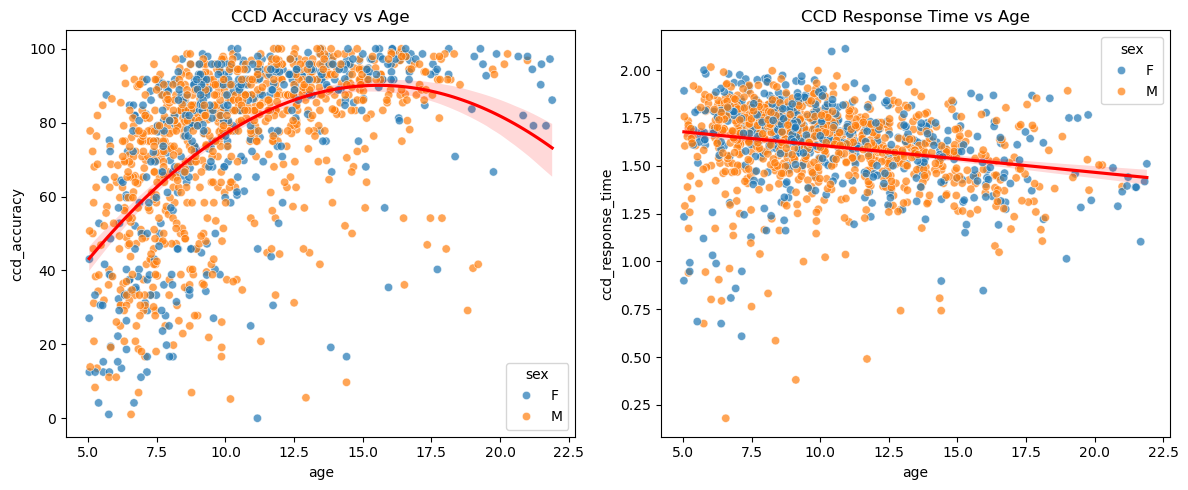

In [11]:
# --- 4. Task performance vs Age (same as before) ---
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)
sns.scatterplot(data=df, x="age", y="ccd_accuracy", hue="sex", alpha=0.7, ax=axes[0])
sns.regplot(data=df, x="age", y="ccd_accuracy", scatter=False, order=2, color="red", ax=axes[0])
axes[0].set_title("CCD Accuracy vs Age")

sns.scatterplot(data=df, x="age", y="ccd_response_time", hue="sex", alpha=0.7, ax=axes[1])
sns.regplot(data=df, x="age", y="ccd_response_time", scatter=False, color="red", ax=axes[1])
axes[1].set_title("CCD Response Time vs Age")

plt.tight_layout()
plt.show()


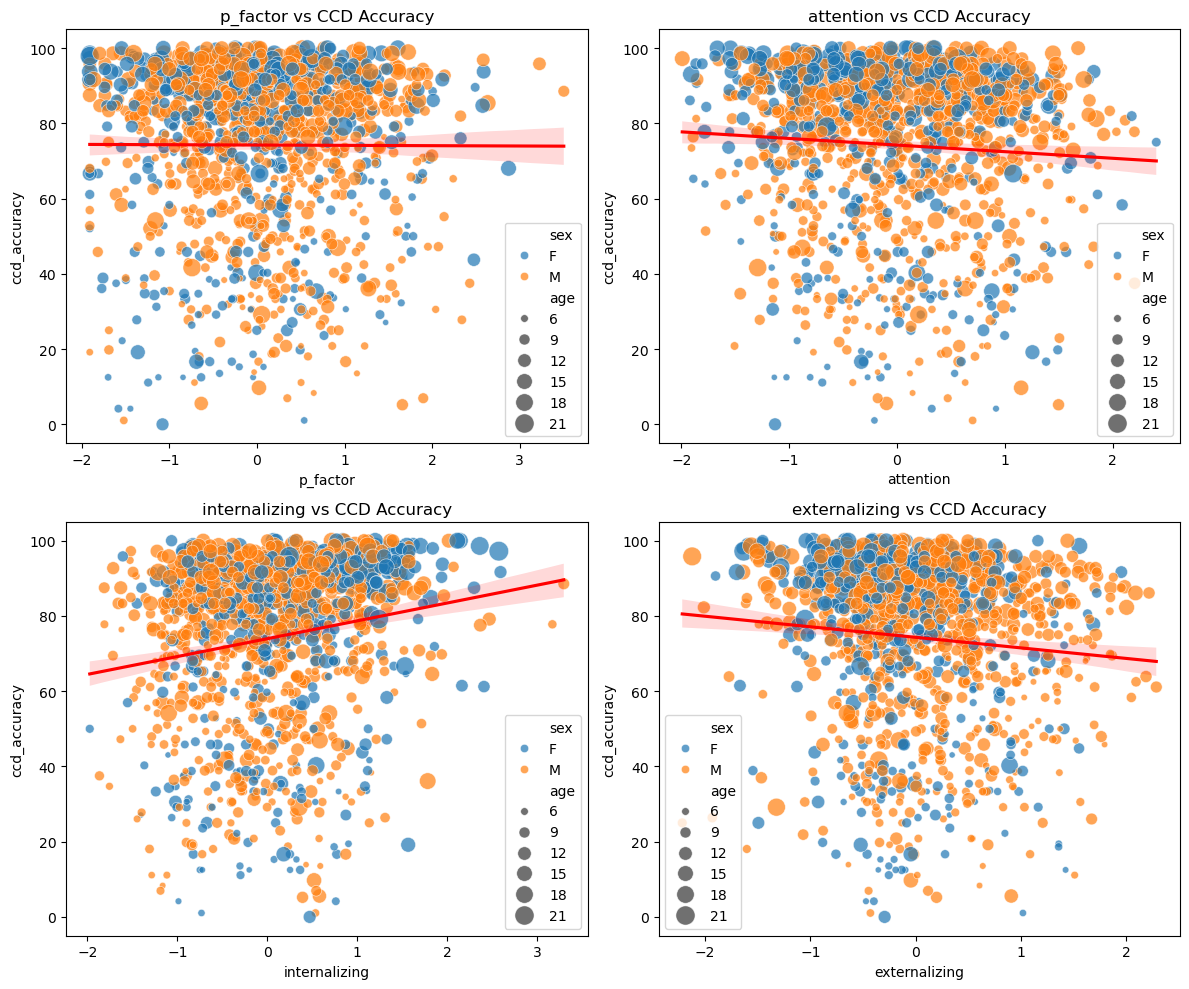

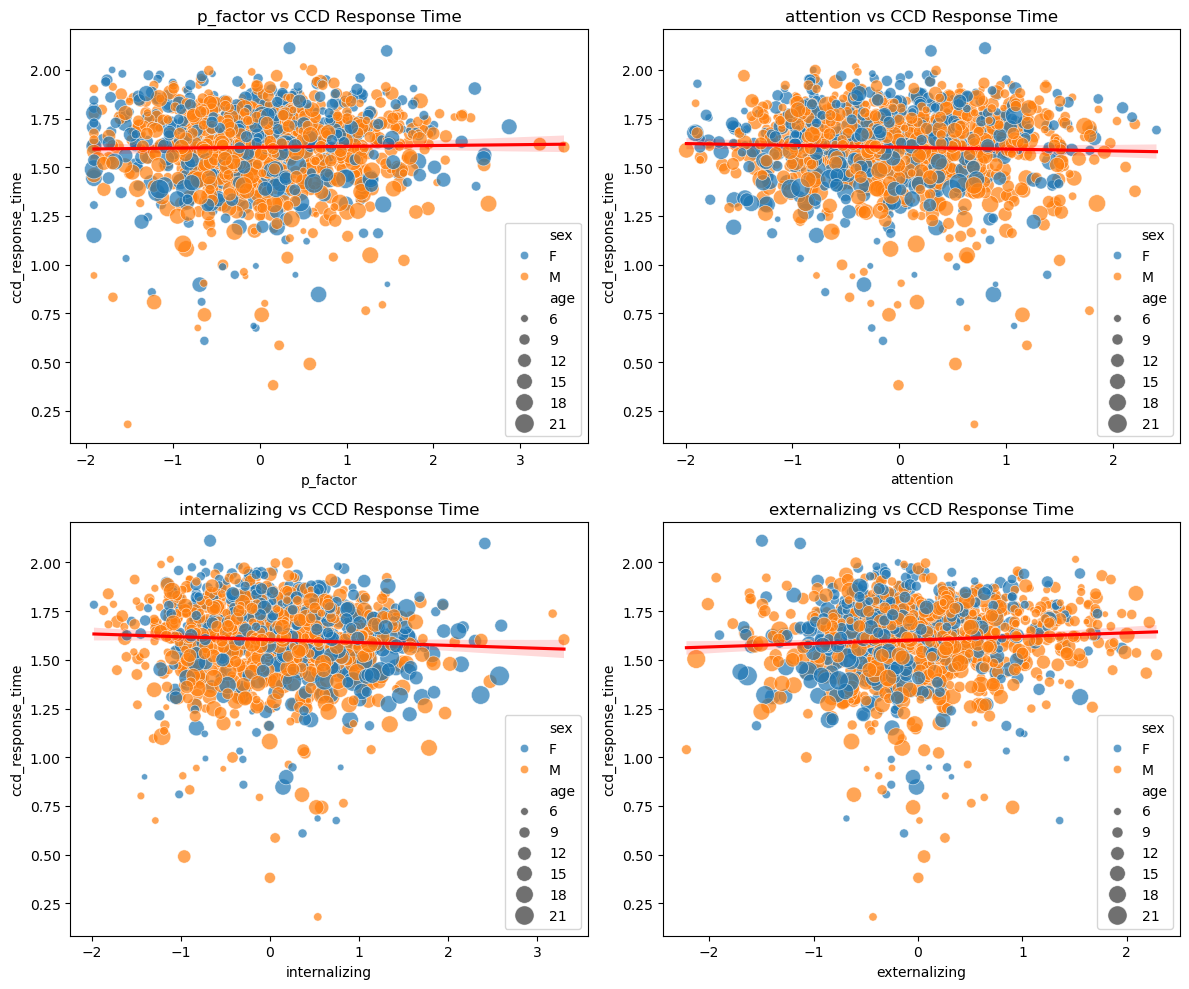

In [12]:
# --- 5. Psychopathology factors vs Task Performance (sex=color, age=size) ---
factors = ["p_factor", "attention", "internalizing", "externalizing"]

fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, factor in zip(axes.flat, factors):
    sns.scatterplot(
        data=df, x=factor, y="ccd_accuracy",
        hue="sex", size="age", alpha=0.7, ax=ax, sizes=(20,200)
    )
    sns.regplot(data=df, x=factor, y="ccd_accuracy", scatter=False, color="red", ax=ax)
    ax.set_title(f"{factor} vs CCD Accuracy")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, factor in zip(axes.flat, factors):
    sns.scatterplot(
        data=df, x=factor, y="ccd_response_time",
        hue="sex", size="age", alpha=0.7, ax=ax, sizes=(20,200)
    )
    sns.regplot(data=df, x=factor, y="ccd_response_time", scatter=False, color="red", ax=ax)
    ax.set_title(f"{factor} vs CCD Response Time")

plt.tight_layout()
plt.show()

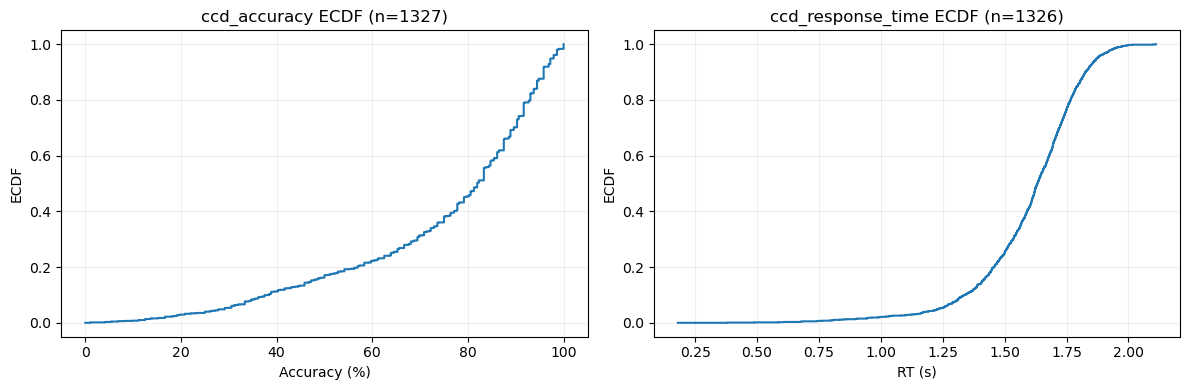

In [13]:
# ECDFs for CCD metrics (distribution shape without binning)
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["ccd_accuracy", "ccd_response_time"], ["Accuracy (%)", "RT (s)"]):
    x = np.sort(df[col].dropna().to_numpy()) if col in df.columns else np.array([])
    if x.size:
        y = np.linspace(0, 1, x.size, endpoint=True)
        ax.plot(x, y, drawstyle="steps-post")
        ax.set_xlabel(title)
        ax.set_ylabel("ECDF")
        ax.set_title(f"{col} ECDF (n={x.size})")
        ax.grid(alpha=0.2)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_axis_off()
plt.tight_layout()
plt.show()

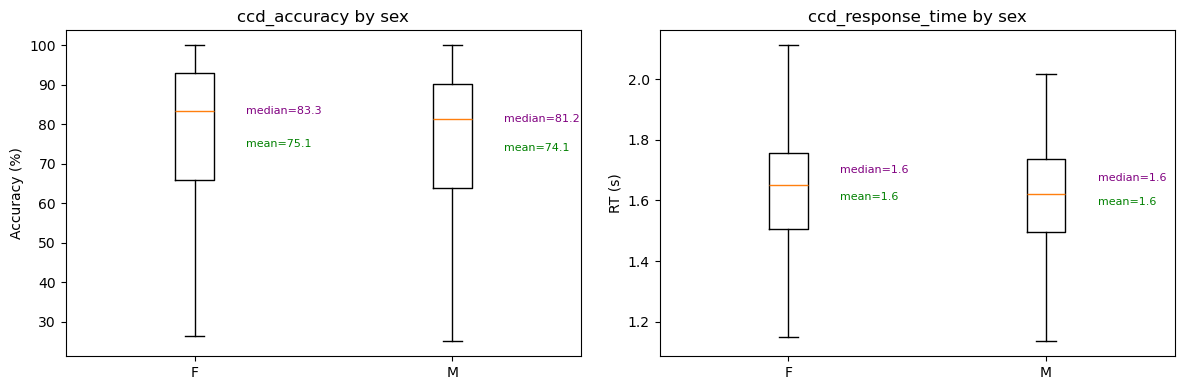

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, ylabel in zip(axes, ["ccd_accuracy", "ccd_response_time"], ["Accuracy (%)", "RT (s)"]):
    g = df.loc[df[col].notna() & df["sex"].notna(), ["sex", col]].copy()
    
    # Groups and labels
    groups = [vals[col].to_numpy() for _, vals in g.groupby("sex")]
    labels = [str(name) for name, _ in g.groupby("sex")]
    
    ax.boxplot(groups, tick_labels=labels, showfliers=False)
    ax.set_title(f"{col} by sex")
    ax.set_ylabel(ylabel)

    # Compute summary stats
    summary = g.groupby("sex")[col].agg(["median", "mean"])

    # Annotate each group
    for i, sex in enumerate(summary.index, start=1):
        median_val = summary.loc[sex, "median"]
        mean_val = summary.loc[sex, "mean"]

        # Default positions
        y_median, y_mean = median_val, mean_val

        # If too close, move the higher one up
        space = 0.05
        if abs(mean_val - median_val) < space:
            if mean_val > median_val:
                y_mean += space
            else:
                y_median += space

        ax.text(i + 0.2, y_median, f"median={median_val:.1f}",
                ha="left", va="center", fontsize=8, color="purple")
        ax.text(i + 0.2, y_mean, f"mean={mean_val:.1f}",
                ha="left", va="center", fontsize=8, color="green")

plt.tight_layout()
plt.show()


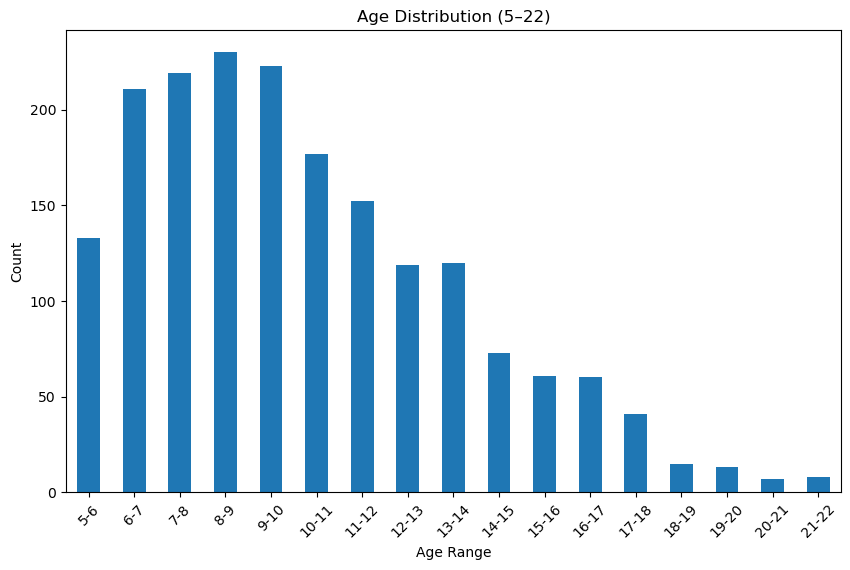

In [15]:
bins = list(range(5, 23))   # 5, 6, ..., 22
labels = [f"{i}-{i+1}" for i in range(5, 22)]

# Cut ages into bins
df['age_group'] = pd.cut(df['age'], bins=bins, right=False, labels=labels)

# Count values per age group
age_counts = df['age_group'].value_counts().sort_index()

# Plot bar chart
age_counts.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.title("Age Distribution (5–22)")
plt.xticks(rotation=45)
plt.show()

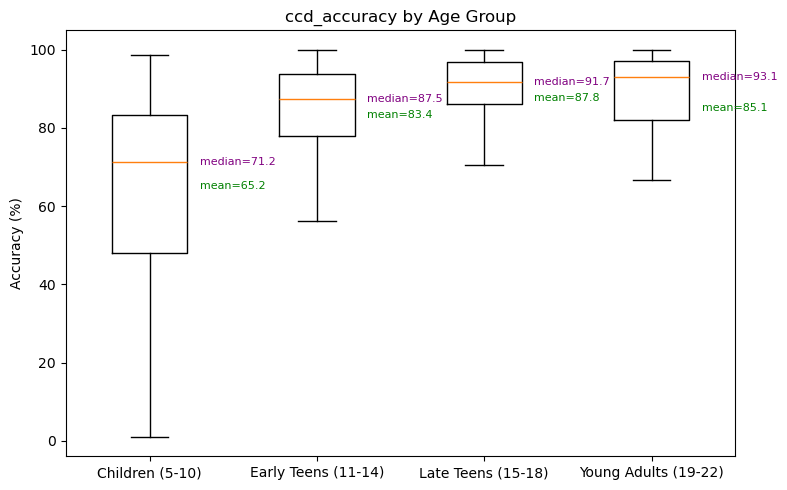

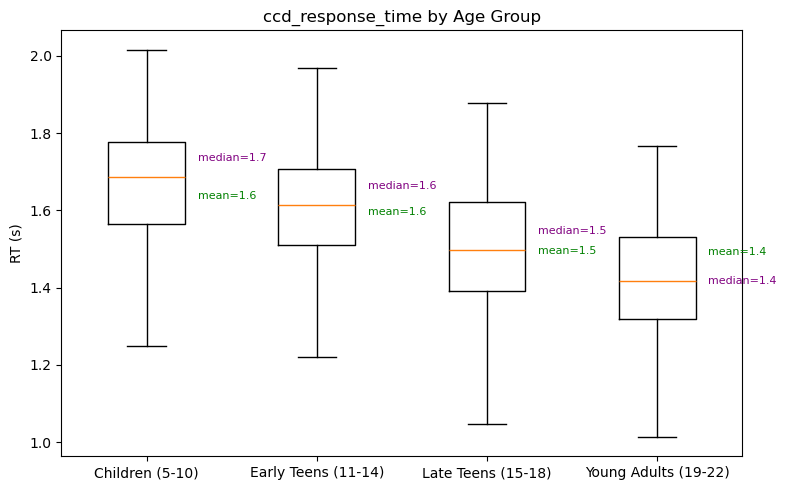

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ages = pd.to_numeric(df["age"], errors="coerce")

# Define bins and labels
bins = [5, 10, 14, 18, 22]
labels = ["Children (5-10)", "Early Teens (11-14)", "Late Teens (15-18)", "Young Adults (19-22)"]

age_grp = pd.cut(ages, bins=bins, labels=labels, right=True, include_lowest=True)
df2 = df.assign(age_group=age_grp)

# Function to plot each metric separately
def plot_by_group(metric, ylabel):
    g = df2.loc[df2[metric].notna() & df2["age_group"].notna(), ["age_group", metric]]
    if g.empty:
        print(f"No data for {metric}")
        return
    
    # Build groups dynamically
    groups = []
    tick_labels = []
    for grp, vals in g.groupby("age_group", observed=True):
        groups.append(vals[metric].to_numpy())
        tick_labels.append(grp)

    # Compute summary stats
    summary = g.groupby("age_group", observed=True)[metric].agg(["median", "mean"])

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(groups, tick_labels=tick_labels, showfliers=False)  # keep outliers
    ax.set_title(f"{metric} by Age Group")
    ax.set_ylabel(ylabel)

    # Annotate median + mean to the right of the box
    for i, grp in enumerate(tick_labels, start=1):
        if grp in summary.index:
            stats = summary.loc[grp]
            median_val = stats["median"]
            mean_val = stats["mean"]

            # Default positions
            y_median, y_mean = median_val, mean_val

            # If too close, move the higher one up
            space = 0.05
            if abs(mean_val - median_val) < space:
                if mean_val > median_val:
                    y_mean += space
                else:
                    y_median += space

            ax.text(i + 0.3, y_median, f"median={median_val:.1f}",
                    ha="left", va="center", fontsize=8, color="purple")
            ax.text(i + 0.3, y_mean, f"mean={mean_val:.1f}",
                    ha="left", va="center", fontsize=8, color="green")


    plt.tight_layout()
    plt.show()

# Run for both metrics
plot_by_group("ccd_accuracy", "Accuracy (%)")
plot_by_group("ccd_response_time", "RT (s)")


acc_thresh = 81.9444 rt_thresh = 1.6324
perf_group
LowAcc-Slow     934
HighAcc-Fast    415
HighAcc-Slow    265
LowAcc-Fast     248
Name: count, dtype: int64


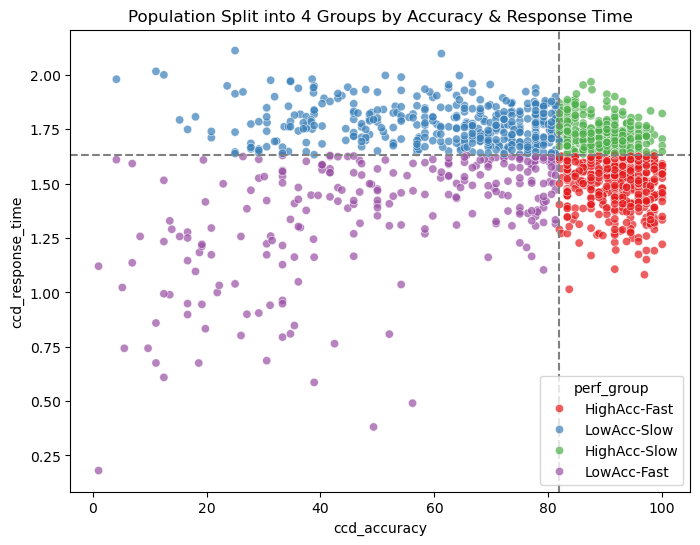

In [17]:
import numpy as np

# --- Define thresholds (using median, but you could use mean or custom cutoff) ---
acc_thresh = df["ccd_accuracy"].median()
rt_thresh = df["ccd_response_time"].median()

# --- Create group column ---
def assign_group(row):
    if row["ccd_accuracy"] >= acc_thresh and row["ccd_response_time"] <= rt_thresh:
        return "HighAcc-Fast"
    elif row["ccd_accuracy"] >= acc_thresh and row["ccd_response_time"] > rt_thresh:
        return "HighAcc-Slow"
    elif row["ccd_accuracy"] < acc_thresh and row["ccd_response_time"] <= rt_thresh:
        return "LowAcc-Fast"
    else:
        return "LowAcc-Slow"
print("acc_thresh = " + str(acc_thresh), "rt_thresh = " + str(rt_thresh))

df["perf_group"] = df.apply(assign_group, axis=1)

# --- Check group counts ---
print(df["perf_group"].value_counts())

# --- Visualize the 4 groups ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="ccd_accuracy", y="ccd_response_time",
    hue="perf_group", palette="Set1", alpha=0.7
)
plt.axvline(acc_thresh, color="grey", linestyle="--")
plt.axhline(rt_thresh, color="grey", linestyle="--")
plt.title("Population Split into 4 Groups by Accuracy & Response Time")
plt.show()


acc_thresh = 74.43345207234363 rt_thresh = 1.6002249622926092
perf_group
LowAcc-Slow     850
HighAcc-Slow    460
HighAcc-Fast    388
LowAcc-Fast     164
Name: count, dtype: int64


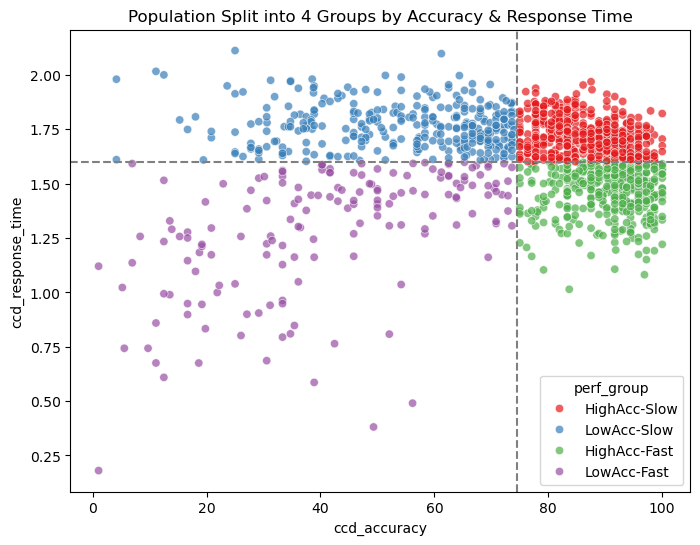

In [18]:
import numpy as np

# --- Define thresholds (using median, but you could use mean or custom cutoff) ---
acc_thresh = df["ccd_accuracy"].mean()
rt_thresh = df["ccd_response_time"].mean()

# --- Create group column ---
def assign_group(row):
    if row["ccd_accuracy"] >= acc_thresh and row["ccd_response_time"] <= rt_thresh:
        return "HighAcc-Fast"
    elif row["ccd_accuracy"] >= acc_thresh and row["ccd_response_time"] > rt_thresh:
        return "HighAcc-Slow"
    elif row["ccd_accuracy"] < acc_thresh and row["ccd_response_time"] <= rt_thresh:
        return "LowAcc-Fast"
    else:
        return "LowAcc-Slow"
print("acc_thresh = " + str(acc_thresh), "rt_thresh = " + str(rt_thresh))

df["perf_group"] = df.apply(assign_group, axis=1)

# --- Check group counts ---
print(df["perf_group"].value_counts())

# --- Visualize the 4 groups ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="ccd_accuracy", y="ccd_response_time",
    hue="perf_group", palette="Set1", alpha=0.7
)
plt.axvline(acc_thresh, color="grey", linestyle="--")
plt.axhline(rt_thresh, color="grey", linestyle="--")
plt.title("Population Split into 4 Groups by Accuracy & Response Time")
plt.show()


perf_group
LowAcc-Slow     850
HighAcc-Slow    460
HighAcc-Fast    388
LowAcc-Fast     164
Name: count, dtype: int64


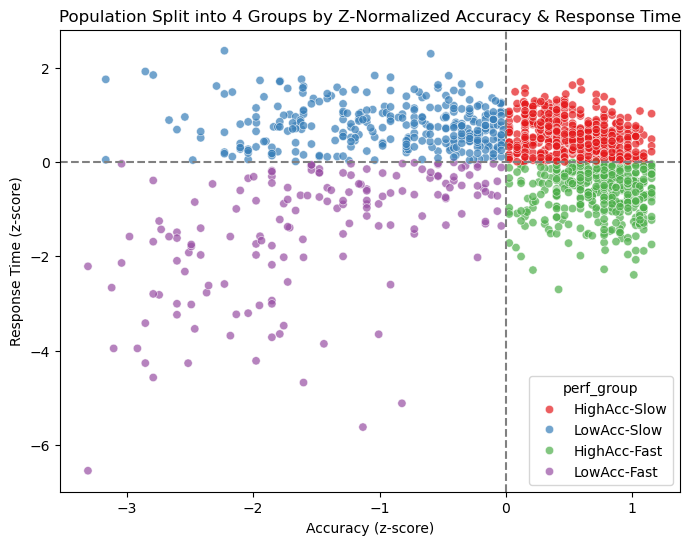

In [19]:
import numpy as np

# --- Z-normalize columns ---
df["acc_z"] = (df["ccd_accuracy"] - df["ccd_accuracy"].mean()) / df["ccd_accuracy"].std()
df["rt_z"]  = (df["ccd_response_time"] - df["ccd_response_time"].mean()) / df["ccd_response_time"].std()

# --- Thresholds (z=0 corresponds to the mean) ---
acc_thresh = 0
rt_thresh = 0

# --- Assign groups using z-scores ---
def assign_group(row):
    if row["acc_z"] >= acc_thresh and row["rt_z"] <= rt_thresh:
        return "HighAcc-Fast"
    elif row["acc_z"] >= acc_thresh and row["rt_z"] > rt_thresh:
        return "HighAcc-Slow"
    elif row["acc_z"] < acc_thresh and row["rt_z"] <= rt_thresh:
        return "LowAcc-Fast"
    else:
        return "LowAcc-Slow"

df["perf_group"] = df.apply(assign_group, axis=1)

# --- Check group counts ---
print(df["perf_group"].value_counts())

# --- Visualize ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="acc_z", y="rt_z",
    hue="perf_group", palette="Set1", alpha=0.7
)
plt.axvline(acc_thresh, color="grey", linestyle="--")
plt.axhline(rt_thresh, color="grey", linestyle="--")
plt.title("Population Split into 4 Groups by Z-Normalized Accuracy & Response Time")
plt.xlabel("Accuracy (z-score)")
plt.ylabel("Response Time (z-score)")
plt.show()


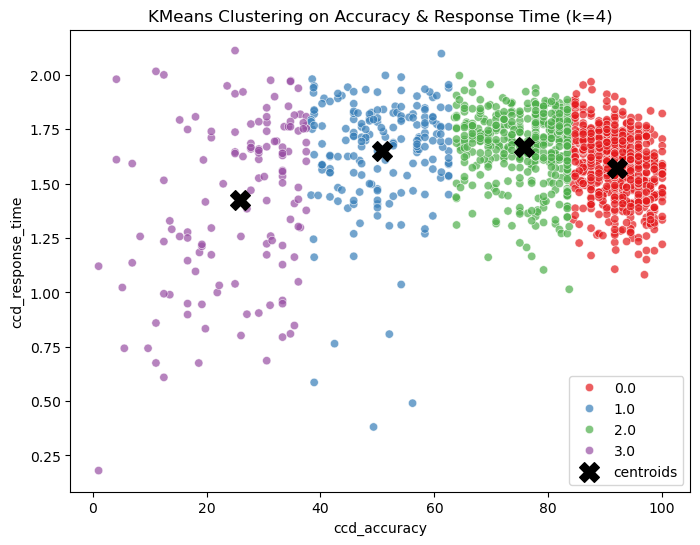

                   ccd_accuracy  ccd_response_time
perf_group_kmeans                                 
0.0                   92.079041           1.573314
1.0                   50.855663           1.650259
2.0                   75.800111           1.670218
3.0                   25.828000           1.424845


In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- Select features for clustering ---
X = df[["ccd_accuracy", "ccd_response_time"]].dropna()

# --- Run KMeans with 4 clusters ---
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

# --- Attach results ---
df["perf_group_kmeans"] = np.nan
df.loc[X.index, "perf_group_kmeans"] = clusters

# --- Visualize ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="ccd_accuracy", y="ccd_response_time",
    hue="perf_group_kmeans", palette="Set1", alpha=0.7
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200, c="black", marker="X", label="centroids"
)
plt.title("KMeans Clustering on Accuracy & Response Time (k=4)")
plt.legend()
plt.show()

# --- Cluster summaries ---
print(df.groupby("perf_group_kmeans")[["ccd_accuracy", "ccd_response_time"]].mean())
